In [1]:
import sys, os
from pathlib import Path

IS_KAGGLE = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '') != ''

if IS_KAGGLE:
    # Install packages not available on Kaggle
    %pip install -q kymatio kornia
    
    # Add repo to path (UPDATE 'deep-learning-course-project' to your dataset slug)
    repo_path = Path('/kaggle/input/d/giladnavok/deep-learning-course-project/')
    if repo_path.exists():
        sys.path.insert(0, str(repo_path))
else:
    # Local: add project root to path (assumes notebook is in notebooks/)
    project_root = Path.cwd().parent
    if (project_root / 'src').exists():
        sys.path.insert(0, str(project_root))

from src.utils.config import *
from src.utils.datasets import *
from src.models.architectures.RestNet18 import *
from src.utils.training import *
from src.utils.visualization import *

from typing import Dict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 4.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
====================== Hyperparameters =======================
N_EPOCHS: 200
T_MAX: 200
CRITERION: CrossEntropyLoss()
DEVICE: cuda
SEED: 42
BATCH_SIZE: 128
LR: 0.001
MOMENTUM: 0.9
WEIGHT_DECAY: 0.0001
Setting seed to 42


In [2]:
DEBUG = False
SKIP_TRAINING = False
EXP_NAME = "baseline_acc_vs_n_samples"
print(f"Starting experiment {EXP_NAME}. DEBUG={DEBUG}, SKIP_TRAINING={SKIP_TRAINING}")

device = DEVICE

n_samples_per_class_train = [200, 300, 400]

Starting experiment baseline_acc_vs_n_samples. DEBUG=False, SKIP_TRAINING=False


In [3]:
test_accs : dict[int, float] = {}

# Train and save model for each data size
for n_samples in n_samples_per_class_train:
    # Initialize model
    resnet = MakeResNet18().to(device)
    MODEL_NAME = f"ResNet18_{n_samples}"

    total_params, model_size_mb = get_model_summary(resnet)
    print(f"Total Parameters: {total_params:,}")
    print(f"Model Size: {model_size_mb:.2f} MB")

    # Get data loaders
    trainloader, valloader, testloader, train_set, val_set, test_set = get_cifar10_loaders_and_splits(
    n_samples_per_class_train=n_samples
    )
    resnet_optimizer, resnet_scheduler = get_optimizer_and_scheduler(resnet)

    # Train model on n_samples
    if not SKIP_TRAINING:
        train_model(
            model=resnet,
            trainloader=trainloader,
            valloader=valloader,
            optimizer=resnet_optimizer,
            scheduler=resnet_scheduler,
            device=device,
            experiment_name=EXP_NAME,
            model_name=MODEL_NAME,
            val_accuracy_storing_threshold=0,
            print_progress_every=50,
            DEBUG=DEBUG
        )

        # Save accuracy on test set
        debug_suff = "_DEBUG" if DEBUG else ""
        load_weights(resnet, experiment_name=EXP_NAME, model_name=(MODEL_NAME+ debug_suff), device=device)
        test_acc = calculate_accuracy(resnet, testloader, device)
        test_accs[n_samples] = test_acc
        print(f'Final test accuracy is: {test_acc:.3f}')

Total Parameters: 11,173,962
Model Size: 42.63 MB


100%|██████████| 170M/170M [00:03<00:00, 49.1MB/s]


Using default 500 samples per class for val.
Original train-val size: 50000
Train size: 2000
Val size: 5000
Test size: 10000
Samples per class (train): Counter({np.int64(6): 200, np.int64(2): 200, np.int64(8): 200, np.int64(5): 200, np.int64(7): 200, np.int64(4): 200, np.int64(9): 200, np.int64(3): 200, np.int64(1): 200, np.int64(0): 200})
Samples per class (val): Counter({np.int64(2): 500, np.int64(9): 500, np.int64(5): 500, np.int64(6): 500, np.int64(0): 500, np.int64(7): 500, np.int64(3): 500, np.int64(4): 500, np.int64(8): 500, np.int64(1): 500})
Model weights will be saved to: /kaggle/working/artifacts/checkpoints/baseline_acc_vs_n_samples_ResNet18_200.pth
Stats will be saved to: /kaggle/working/artifacts/stats/baseline_acc_vs_n_samples_ResNet18_200.pkl

=== Starting Training: ResNet18_200 with 200 epochs ===
    --> New Best Saved: 10.00%
Epoch 1/200 | Loss: 4.262 | Val Acc: 10.00%
    --> New Best Saved: 49.86%
Epoch 51/200 | Loss: 0.559 | Val Acc: 49.86%
Epoch 101/200 | Loss: 0

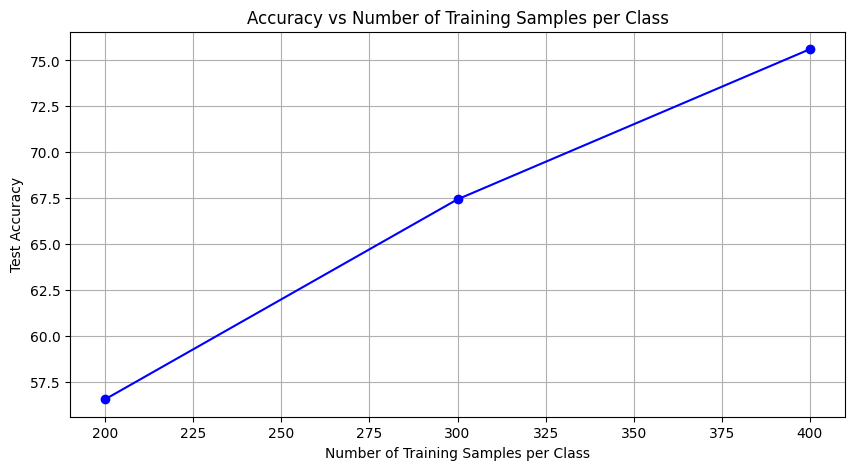

In [4]:
# Plot accuracy vs data size
plt.figure(figsize=(10, 5))
plt.plot(list(test_accs.keys()), list(test_accs.values()), marker='o', linestyle='-', color='b')
plt.xlabel('Number of Training Samples per Class')
plt.ylabel('Test Accuracy')
plt.title('Accuracy vs Number of Training Samples per Class')
plt.grid(True)
if not SKIP_TRAINING:
    plt.savefig(FIGURES_PATH / 'baseline_acc_vs_n_samples.png')
plt.show()